In [1]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam
print(tf.__version__)

2.21.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [4]:
data = pd.read_csv('../datasets/acc_data.csv')
data.head()

,TIMESTAMP,INDEX,ACC_X,ACC_Y,ACC_Z,GESTURE
0,2.024110e+13,1,-365,26,905,1
1,2.024110e+13,1,-108,42,1007,1
2,2.024110e+13,1,-205,81,1003,1
3,2.024110e+13,1,-166,34,1003,1
4,2.024110e+13,1,-139,65,983,1


In [5]:
data.shape

(200860, 6)

In [6]:
data.columns = data.columns.str.strip()

In [7]:
for i in range(0, len(data), 1):
    if(data['GESTURE'][i] == 1):
        data['GESTURE'][i] = 'Forward'
    elif(data['GESTURE'][i] == 2):
        data['GESTURE'][i] = 'Back'
    elif(data['GESTURE'][i] == 3):
        data['GESTURE'][i] = 'Right'
    elif(data['GESTURE'][i] == 4):
        data['GESTURE'][i] = 'Left'
    elif(data['GESTURE'][i] == 5):
        data['GESTURE'][i] = 'Up'
    elif(data['GESTURE'][i] == 6):
        data['GESTURE'][i] = 'Down'
    elif(data['GESTURE'][i] == 7):
        data['GESTURE'][i] = 'Stop'

C:\Users\User\AppData\Local\Temp\ipykernel_17232\4181257459.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['GESTURE'][i] = 'Forward'
C:\Users\User\AppData\Local\Temp\ipykernel_17232\4181257459.py:3: SettingWithCopyWarning: 
A value

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200860 entries, 0 to 200859
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   TIMESTAMP  200860 non-null  float64
 1   INDEX      200860 non-null  int64  
 2   ACC_X      200860 non-null  int64  
 3   ACC_Y      200860 non-null  int64  
 4   ACC_Z      200860 non-null  int64  
 5   GESTURE    200860 non-null  object 
dtypes: float64(1), int64(4), object(1)
memory usage: 9.2+ MB


In [9]:
data.isnull().sum()

TIMESTAMP    0
INDEX        0
ACC_X        0
ACC_Y        0
ACC_Z        0
GESTURE      0
dtype: int64

In [10]:
data['GESTURE'].value_counts()

GESTURE
Forward    104778
Back        96082
Name: count, dtype: int64

In [11]:
Fs = 50
gestures = data['GESTURE'].value_counts().index
gestures

Index(['Forward', 'Back'], dtype='object', name='GESTURE')

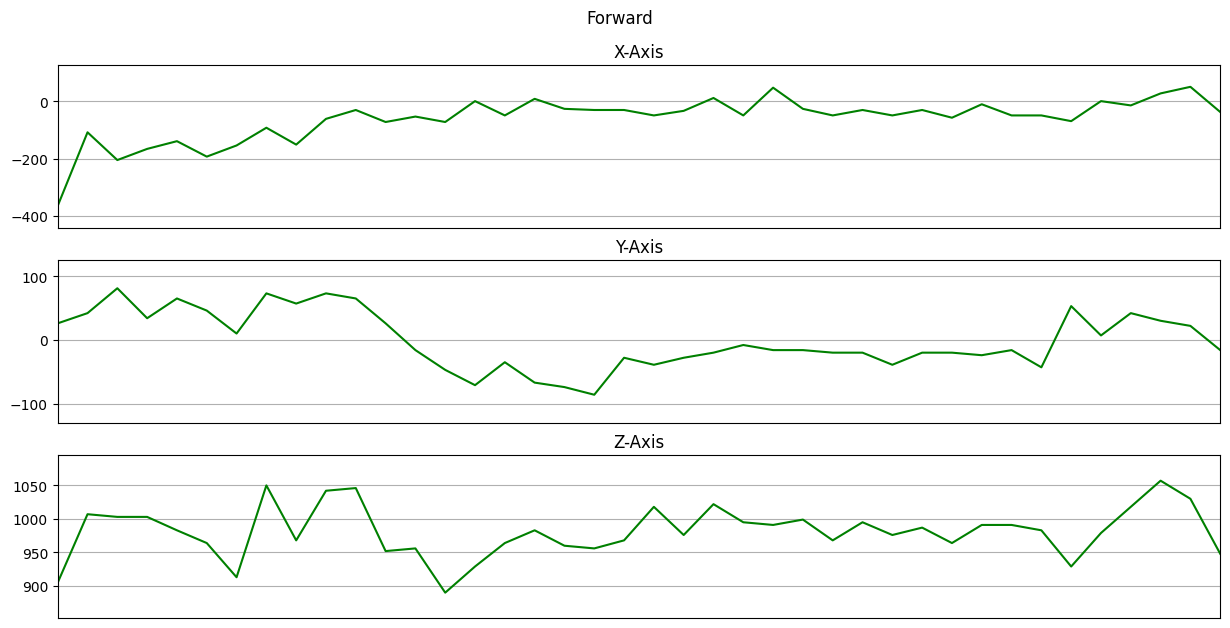

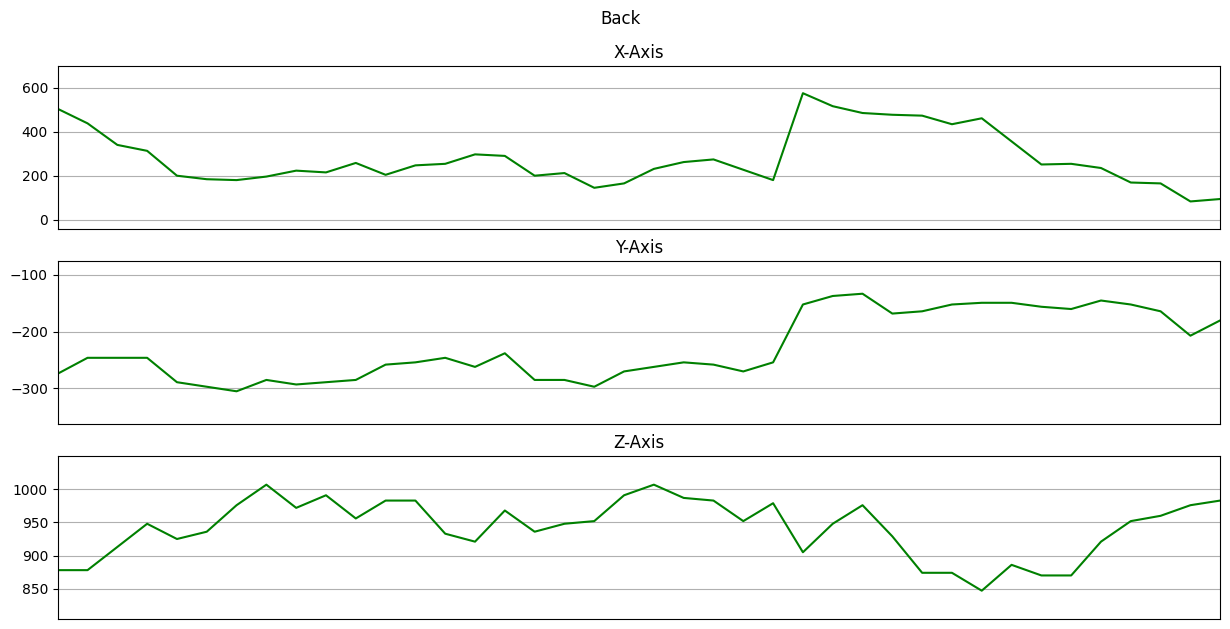

In [47]:
def plot_gesture(activity, data):
    fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(15, 7), sharex=True)
    time_steps = np.arange(len(data)) / Fs    

    plot_axis(ax0, time_steps, data['ACC_X'], 'X-Axis')
    plot_axis(ax1, time_steps, data['ACC_Y'], 'Y-Axis')
    plot_axis(ax2, time_steps, data['ACC_Z'], 'Z-Axis')
    plt.subplots_adjust(hspace=0.2)
    fig.suptitle(activity)
    plt.subplots_adjust(top=0.90)
    plt.show()

def plot_axis(ax, x, y, title):
    ax.plot(x, y, 'g')
    ax.set_title(title)
    ax.xaxis.set_visible(False)
    ax.set_ylim([min(y) - np.std(y), max(y) + np.std(y)])
    ax.set_xlim([min(x), max(x)])
    ax.grid(True)

for gesture in gestures:
    data_for_plot = data[(data['GESTURE'] == gesture)][:Fs*4]
    plot_gesture(gesture, data_for_plot)

In [13]:
df = data.drop(['INDEX', 'TIMESTAMP'], axis = 1).copy()
df.head()

,ACC_X,ACC_Y,ACC_Z,GESTURE
0,-365,26,905,Forward
1,-108,42,1007,Forward
2,-205,81,1003,Forward
3,-166,34,1003,Forward
4,-139,65,983,Forward


In [14]:
label = LabelEncoder()
df['GESTURE'] = label.fit_transform(df['GESTURE'])
df['GESTURE'].value_counts()

GESTURE
1    104778
0     96082
Name: count, dtype: int64

In [15]:
label.classes_

array(['Back', 'Forward'], dtype=object)

In [16]:
X = df[['ACC_X', 'ACC_Y', 'ACC_Z']]
y = df['GESTURE']

In [17]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

scaled_X = pd.DataFrame(data = X, columns = ['ACC_X', 'ACC_Y', 'ACC_Z'])
scaled_X['GESTURE'] = y.values

scaled_X.head()

,ACC_X,ACC_Y,ACC_Z,GESTURE
0,-1.718061,1.004786,0.346509,1
1,-0.645684,1.104779,0.496248,1
2,-1.050433,1.348514,0.490376,1
3,-0.887699,1.054783,0.490376,1
4,-0.775037,1.248520,0.461015,1


In [18]:
import scipy.stats as stats

In [19]:
Fs = 10
frame_size = Fs*5 # 50
hop_size = Fs # 10

In [22]:
def get_frames(df, frame_size, hop_size):

    N_FEATURES = 3

    frames = []
    labels = []
    for i in range(0, len(df) - frame_size, hop_size):
        x = df['ACC_X'].values[i: i + frame_size]
        y = df['ACC_Y'].values[i: i + frame_size]
        z = df['ACC_Z'].values[i: i + frame_size]
        
        # Retrieve the most often used label in this segment
        label = df['GESTURE'][i: i + frame_size].mode()[0]
        frames.append([x, y, z])
        labels.append(label)

#     print(frames[0])
    # Bring the segments into a better shape
    frames = np.asarray(frames).reshape(-1, frame_size, N_FEATURES)
    labels = np.asarray(labels)
#     print(frames[0])

    return frames, labels

X, y = get_frames(scaled_X, frame_size, hop_size)

X.shape, y.shape

((20081, 50, 3), (20081,))

In [23]:
(3555*6)/40

533.25

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0, stratify = y)

In [25]:
X_train.shape, X_test.shape

((16064, 50, 3), (4017, 50, 3))

In [26]:
X_train[0].shape, X_test[0].shape

((50, 3), (50, 3))

In [29]:
X_train = X_train.reshape(16064, 50, 3, 1)
X_test = X_test.reshape(4017, 50, 3, 1)

In [31]:
X_train[0].shape, X_test[0].shape

((50, 3, 1), (50, 3, 1))

In [32]:
model = Sequential()
model.add(Conv2D(16, (2, 2), activation = 'relu', input_shape = X_train[0].shape))
model.add(Dropout(0.1))

model.add(Conv2D(32, (2, 2), activation='relu'))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(64, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(7, activation='softmax'))

e:\Work\ML\Directional-Motion-Detection\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.compile(optimizer=Adam(learning_rate = 0.001), loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
history = model.fit(X_train, y_train, epochs = 100, validation_data= (X_test, y_test), verbose=1)

Epoch 1/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7080 - loss: 0.5521 - val_accuracy: 0.7697 - val_loss: 0.4408
Epoch 2/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7583 - loss: 0.4716 - val_accuracy: 0.7792 - val_loss: 0.4293
Epoch 3/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7694 - loss: 0.4578 - val_accuracy: 0.7919 - val_loss: 0.4154
Epoch 4/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7949 - loss: 0.4290 - val_accuracy: 0.8325 - val_loss: 0.3797
Epoch 5/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8191 - loss: 0.3929 - val_accuracy: 0.8626 - val_loss: 0.3338
Epoch 6/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8431 - loss: 0.3565 - val_accuracy: 0.8750 - val_loss: 0.2922
Epoch 7/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8585 - loss: 0.3280 - val_accuracy: 0.8803 - val_loss: 0.2765
Epoch 8/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8696 - loss: 0.3059 - val_accu

In [34]:
def plot_learningCurve(history, epochs):
  # Plot training & validation accuracy values
  epoch_range = range(1, epochs+1)
  plt.plot(epoch_range, history.history['accuracy'])
  plt.plot(epoch_range, history.history['val_accuracy'])
  plt.title('Model accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Val'], loc='upper left')
  plt.show()

  # Plot training & validation loss values
  plt.plot(epoch_range, history.history['loss'])
  plt.plot(epoch_range, history.history['val_loss'])
  plt.title('Model loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Val'], loc='upper left')
  plt.show()

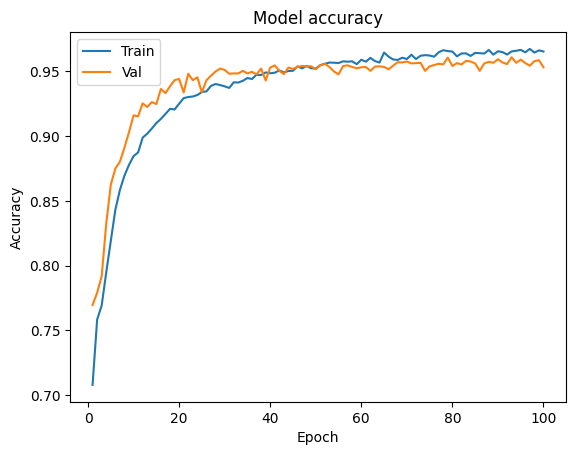

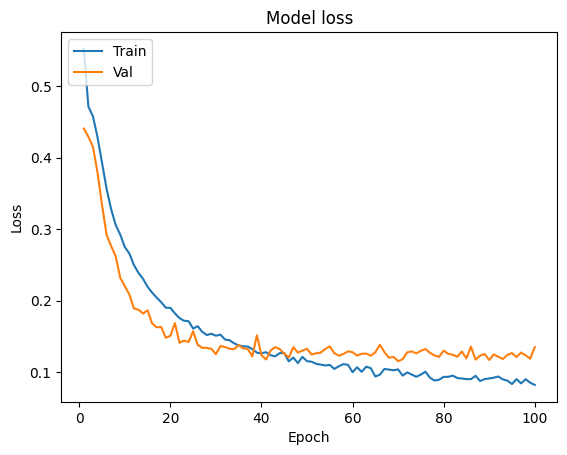

In [35]:
plot_learningCurve(history, 100)

In [36]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix

In [37]:
y_pred = np.argmax(model.predict(X_test), axis=1)

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step


In [38]:
y_pred2 = model.predict(X_test)
np.argmax(y_pred2[0])

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step


np.int64(0)

(<Figure size 700x700 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

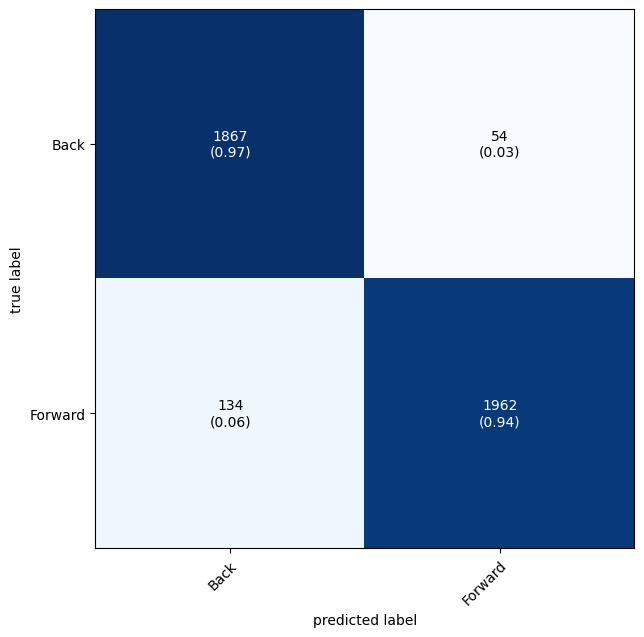

In [39]:
mat = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(conf_mat=mat, class_names=label.classes_, show_normed=True, figsize=(7,7))

In [42]:
model.save_weights('../models/model2.weights.h5')

In [43]:
import pickle

In [44]:
with open('../models/model2_pkl', 'wb') as files:
    pickle.dump(model, files)

In [45]:
y_pred

array([0, 1, 0, ..., 1, 1, 1], shape=(4017,))

In [46]:
y_pred.shape

(4017,)